# Movies Dataset

In [114]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
import numpy as np
import matplotlib.pyplot as plt
import re
import string

In [116]:
RERUN_TUNING = False

## 1. Data Loading

### Loading

In [117]:
from rital.movies.data import load_movies, load_movies_unseen

In [118]:
x, y = load_movies()

In [119]:
x_unseen = load_movies_unseen()

In [120]:
print(np.mean([len(xi) for xi in x]))
print(np.mean([len(xi) for xi in x_unseen]))

3860.642
1325.06964


In [121]:
print(f"Size of Dataset: {len(y)}")
print(f"Number of negative samples: {len(y) - np.sum(y)}")
print(f"Number of positive samples: {np.sum(y)}")

Size of Dataset: 2000
Number of negative samples: 1000
Number of positive samples: 1000


In [122]:
def write_solution(y_pred, file):
    y_pred_pn = ["P\n" if y == 1 else "N\n" for y in y_pred]
    with open(file, "w") as f:
        f.writelines(y_pred_pn)

We don't do any additional preprocessing here as we may choose the preprocessing as a hyperparameter later in our models.

### Matching the unseen data to the current data

The data from the unlabelled dataset is differently formatted from that of the labelled. To do this we will try to preprocess the labelled dataset to match more like that of the unseen data.

In [123]:
print(x[0])
print(x_unseen[0])

the keen wisdom of an elderly bank robber , the naive ambitions of a sexy hospital nurse , and a partnership that blossoms between the two are the fine components that make up a modest , little caper adventure entitled `where the money is . ' the elderly bank robber is henry ( paul newman ) , a famous criminal that was only recently caught . he has pulled off dozens of successful heists and has probably stashed away a small fortune . always the shrewd thinker , he begins working on a plan to get out of jail . this involves years of studying buddhism and self-hypnosis . when he is prepared to execute his plan , he uses what he has learned to fake a stroke . now a seemingly twitching vegetable , he is temporarily transferred to a state-run home . carol ( linda fiorentino ) is the nurse that cares for him . she's a very bright person with a good heart . yet , her life is a miserable waste of time . the most exciting thing to do in town is to fix cars . her days at the hospital facility ar

In [124]:
from rital.movies.preprocessing import normalize

In [125]:
x = [normalize(x_i) for x_i in x]
x_unseen = [normalize(x_i) for x_i in x_unseen]

In [126]:
print(x[0])
print(x_unseen[0])

the keen wisdom of an elderly bank robber, the naive ambitions of a sexy hospital nurse, and a partnership that blossoms between the two are the fine components that make up a modest, little caper adventure entitled `where the money is. ' the elderly bank robber is henry (paul newman), a famous criminal that was only recently caught. he has pulled off dozens of successful heists and has probably stashed away a small fortune. always the shrewd thinker, he begins working on a plan to get out of jail. this involves years of studying buddhism and self-hypnosis. when he is prepared to execute his plan, he uses what he has learned to fake a stroke. now a seemingly twitching vegetable, he is temporarily transferred to a state-run home. carol (linda fiorentino) is the nurse that cares for him. she's a very bright person with a good heart. yet, her life is a miserable waste of time. the most exciting thing to do in town is to fix cars. her days at the hospital facility are spent leading wheelch

## TF-IDF + LinearSVC

In [14]:
def write_results_to_csv(result, file):
    with open(file, "w") as f:
        f.write(
            f"{result['accuracy']:.2f}, {result['f1']:.2f}, {result['precision']:.2f}, {result['recall']:.2f}"
        )

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate

model_svc_default = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC())])

cv = StratifiedKFold(shuffle=True, random_state=0)

scores_svc_default = cross_validate(
    model_svc_default, x, y, cv=cv, scoring=["accuracy", "f1", "precision", "recall"]
)

results_svc_default = {
    "accuracy": np.mean(scores_svc_default["test_accuracy"]),
    "f1": np.mean(scores_svc_default["test_f1"]),
    "precision": np.mean(scores_svc_default["test_precision"]),
    "recall": np.mean(scores_svc_default["test_recall"]),
}

write_results_to_csv(results_svc_default, "results/default-tfidf-linearsvc.csv")

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


def create_confusion_matrix_and_roc_curve(y_true, y_pred, y_pred_proba, save_file=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap="Greens")
    axes[0].set_title("Confusion Matrix")

    # ROC curve
    RocCurveDisplay.from_predictions(y_true, y_pred_proba, ax=axes[1])
    axes[1].set_title("ROC Curve")

    fig.tight_layout()
    if save_file is not None:
        plt.savefig(save_file)
    plt.show()

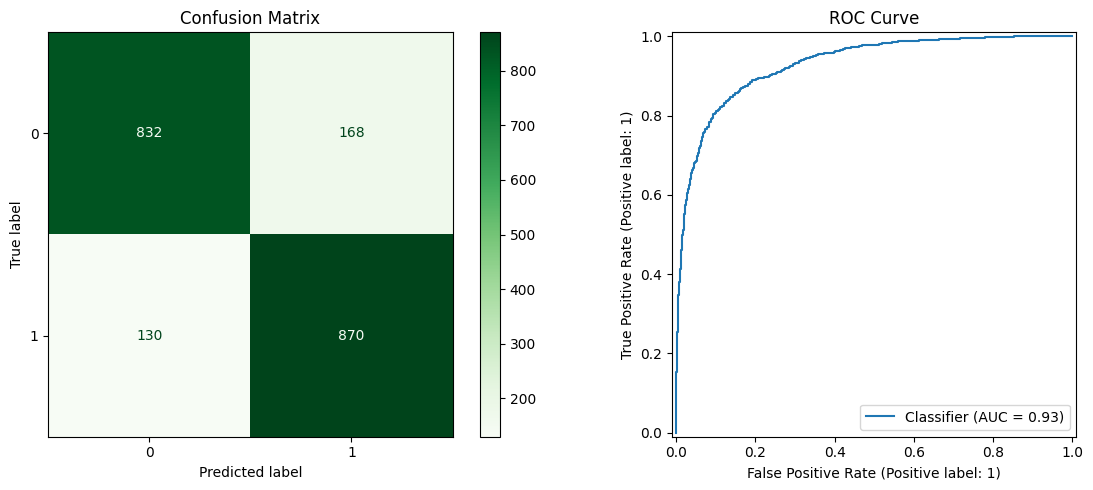

In [17]:
from sklearn.model_selection import cross_val_predict

y_pred_svc_default = cross_val_predict(model_svc_default, x, y, cv=cv)
y_pred_svc_default_proba = cross_val_predict(
    model_svc_default, x, y, cv=cv, method="decision_function"
)  # Not proba in the case of LinearSVC

create_confusion_matrix_and_roc_curve(
    y, y_pred_svc_default, y_pred_svc_default_proba, "figures/cm-roc-svc-default.pdf"
)

In [ ]:
# %%timeit

# model_svc_default.fit(x, y)

541 ms ± 6.53 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
# %%timeit

# pred_svc_default = model_svc_default.predict(x_unseen)

2.13 s ± 12.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
model_svc_default.fit(x, y)
pred_svc_default = model_svc_default.predict(x_unseen)
write_solution(pred_svc_default, "submissions/submission-movie-2-default-svc.csv")

## TF-IDF + Logistic Regression

In [76]:
from sklearn.linear_model import LogisticRegression

model_logreg_default = Pipeline(
    [("tfidf", TfidfVectorizer()), ("clf", LogisticRegression())]
)

scores_logreg_default = cross_validate(
    model_logreg_default, x, y, cv=cv, scoring=["accuracy", "f1", "precision", "recall"]
)

results_logreg_default = {
    "accuracy": np.mean(scores_logreg_default["test_accuracy"]),
    "f1": np.mean(scores_logreg_default["test_f1"]),
    "precision": np.mean(scores_logreg_default["test_precision"]),
    "recall": np.mean(scores_logreg_default["test_recall"]),
}

write_results_to_csv(results_logreg_default, "results/default-tfidf-logreg.csv")

In [ ]:
# %%timeit

# model_logreg_default.fit(x, y)

979 ms ± 99.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
# %%timeit

# pred_logreg_default = model_logreg_default.predict(x_unseen)

2.09 s ± 13.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [20]:
model_logreg_default.fit(x, y)
pred_logreg_default = model_logreg_default.predict(x_unseen)
write_solution(pred_logreg_default, "submissions/submission-movie-3-default-logreg.csv")

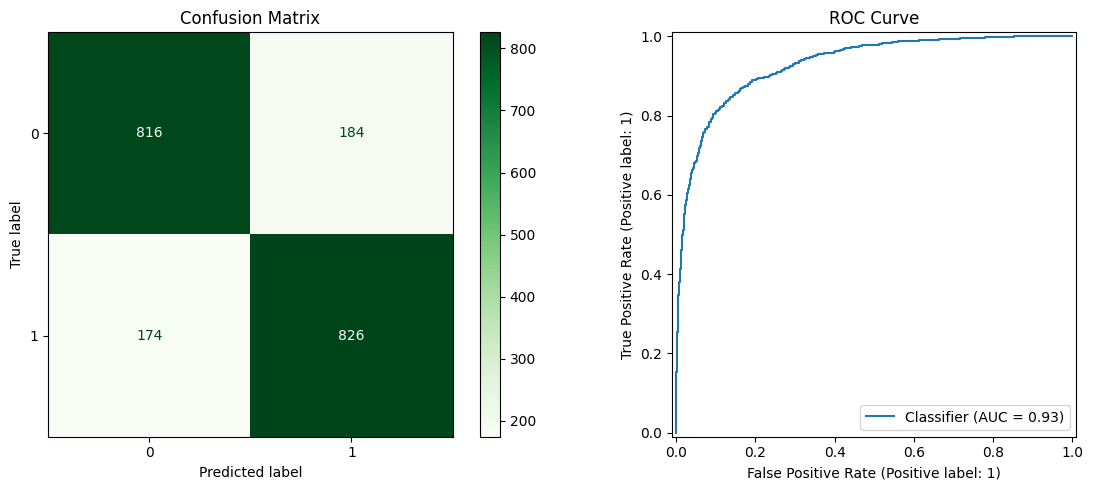

In [21]:
y_pred_logreg_default = cross_val_predict(model_logreg_default, x, y, cv=cv)
y_pred_logreg_default_proba = cross_val_predict(
    model_logreg_default, x, y, cv=cv, method="decision_function"
)  # Not proba in the case of LinearSVC

create_confusion_matrix_and_roc_curve(
    y,
    y_pred_logreg_default,
    y_pred_svc_default_proba,
    "figures/cm-roc-logreg-default.pdf",
)

## Hyperparameter Tuning TF-IDF + LinearSVC

Based on: https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html#sphx-glr-auto-examples-model-selection-plot-nested-cross-validation-iris-py

In [22]:
from sklearn.model_selection import GridSearchCV

### Tuning LinearSVC

In [23]:
if RERUN_TUNING:
    model = Pipeline(
        [
            ("tfidf", TfidfVectorizer()),
            ("clf", LinearSVC()),
        ]
    )

    param_grid = {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 3],
        "tfidf__max_df": [0.9, 1.0],
        "tfidf__sublinear_tf": [False, True],
        "tfidf__stop_words": [None, "english"],
        "clf__C": [1, 10],
    }

    inner_cv = StratifiedKFold(shuffle=True, random_state=0)
    outer_cv = StratifiedKFold(shuffle=True, random_state=1)

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="accuracy",
        n_jobs=-1,
    )

    scores = cross_validate(
        grid,
        x,
        y,
        cv=outer_cv,
        scoring=["accuracy", "f1", "precision", "recall"],
        return_estimator=True,  # lets you inspect best params found in each outer fold
        n_jobs=-1,
    )

    results = {
        "accuracy": np.mean(scores["test_accuracy"]),
        "f1": np.mean(scores["test_f1"]),
        "precision": np.mean(scores["test_precision"]),
        "recall": np.mean(scores["test_recall"]),
    }

    print(results)

    for i, estimator in enumerate(scores["estimator"]):
        print(f"Fold {i + 1} best params: {estimator.best_params_}")

### Tuning Logistic Regression

In [24]:
if RERUN_TUNING:
    model = Pipeline(
        [
            ("tfidf", TfidfVectorizer()),
            ("clf", LogisticRegression()),
        ]
    )

    param_grid = {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 3],
        "tfidf__max_df": [0.9, 1.0],
        "tfidf__sublinear_tf": [False, True],
        "tfidf__stop_words": [None, "english"],
        "clf__C": [1, 10],
    }

    inner_cv = StratifiedKFold(shuffle=True, random_state=0)
    outer_cv = StratifiedKFold(shuffle=True, random_state=1)

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="accuracy",
        n_jobs=-1,
    )

    scores = cross_validate(
        grid,
        x,
        y,
        cv=outer_cv,
        scoring=["accuracy", "f1", "precision", "recall"],
        return_estimator=True,  # lets you inspect best params found in each outer fold
        n_jobs=-1,
    )

    results = {
        "accuracy": np.mean(scores["test_accuracy"]),
        "f1": np.mean(scores["test_f1"]),
        "precision": np.mean(scores["test_precision"]),
        "recall": np.mean(scores["test_recall"]),
    }

    print(results)

    for i, estimator in enumerate(scores["estimator"]):
        print(f"Fold {i + 1} best params: {estimator.best_params_}")

We notice that the best parameter in each does vary. We will choose the best parameters most common.

### Tuned Models

In [25]:
model_svc_tuned = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_df=0.9,
                min_df=3,
                ngram_range=(1, 2),
                sublinear_tf=True,
            ),
        ),
        ("clf", LinearSVC(C=10)),
    ]
)

scores_svc_tuned = cross_validate(
    model_svc_tuned, x, y, cv=cv, scoring=["accuracy", "f1", "precision", "recall"]
)

results_svc_tuned = {
    "accuracy": np.mean(scores_svc_tuned["test_accuracy"]),
    "f1": np.mean(scores_svc_tuned["test_f1"]),
    "precision": np.mean(scores_svc_tuned["test_precision"]),
    "recall": np.mean(scores_svc_tuned["test_recall"]),
}

write_results_to_csv(results_svc_tuned, "results/tuned-tfidf-linearsvc.csv")

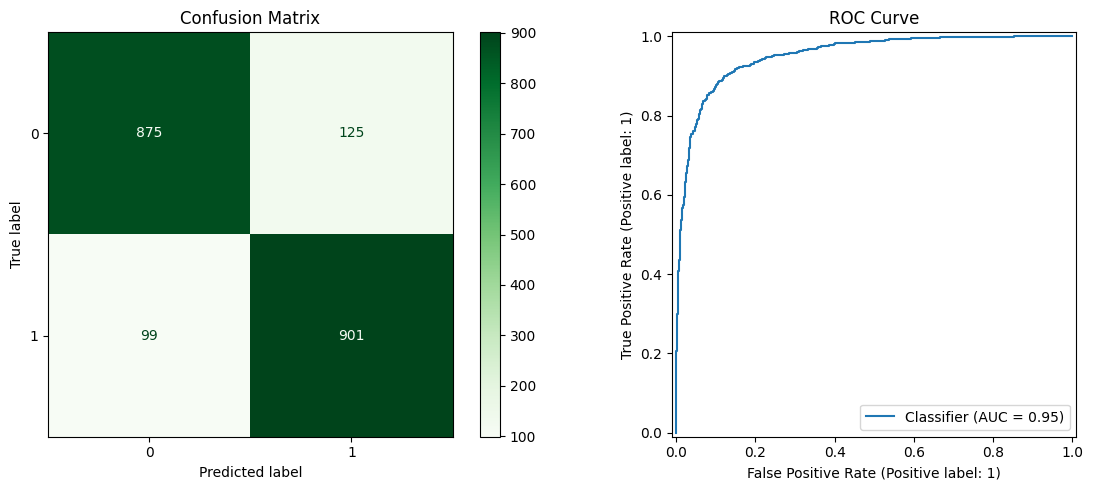

In [26]:
y_pred_svc_tuned = cross_val_predict(model_svc_tuned, x, y, cv=cv)
y_pred_svc_tuned_proba = cross_val_predict(
    model_svc_tuned, x, y, cv=cv, method="decision_function"
)  # Not proba in the case of LinearSVC

create_confusion_matrix_and_roc_curve(
    y, y_pred_svc_tuned, y_pred_svc_tuned_proba, "figures/cm-roc-svc-tuned.pdf"
)

In [79]:
# %%timeit

# model_svc_tuned.fit(x, y)

1.77 s ± 69.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [80]:
# %%timeit

# pred_svc_tuned = model_svc_tuned.predict(x_unseen)

4.16 s ± 16.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [27]:
model_svc_tuned.fit(x, y)
pred_svc_tuned = model_svc_tuned.predict(x_unseen)
write_solution(pred_svc_tuned, "submissions/submission-movie-4-tuned-svc.csv")

In [67]:
from wordcloud import WordCloud


def plot_wordclouds_and_coefficients(model, top_k=20, save_file=None):
    tfidf = model[0]
    clf = model[1]

    features = tfidf.get_feature_names_out()
    coefs = clf.coef_[0]

    # Most positive words
    pos_idx = np.argsort(coefs)[-top_k:]
    pos_words = features[pos_idx]
    pos_scores = coefs[pos_idx]

    pos_order = np.argsort(pos_scores)[::-1]
    pos_words = pos_words[pos_order]
    pos_scores = pos_scores[pos_order]

    # Most negative words
    neg_idx = np.argsort(coefs)[:top_k]
    neg_words = features[neg_idx]
    neg_scores = coefs[neg_idx]

    neg_order = np.argsort(neg_scores)
    neg_words = neg_words[neg_order]
    neg_scores = neg_scores[neg_order]

    # WordCloud needs positive values
    pos_freq = {word: score for word, score in zip(pos_words, pos_scores)}
    neg_freq = {word: abs(score) for word, score in zip(neg_words, neg_scores)}

    wc_pos = WordCloud(
        width=600, height=400, background_color="white"
    ).generate_from_frequencies(pos_freq)

    wc_neg = WordCloud(
        width=600, height=400, background_color="white"
    ).generate_from_frequencies(neg_freq)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Positive wordcloud
    axes[0, 0].imshow(wc_pos, interpolation="bilinear")
    axes[0, 0].axis("off")
    axes[0, 0].set_title("Most Positively Correlated Words")

    # Positive bar chart
    axes[0, 1].barh(pos_words[::-1], pos_scores[::-1])
    axes[0, 1].set_title("Positive Feature Weights")
    axes[0, 1].set_xlabel("Coefficient")

    # Negative wordcloud
    axes[1, 0].imshow(wc_neg, interpolation="bilinear")
    axes[1, 0].axis("off")
    axes[1, 0].set_title("Most Negatively Correlated Words")

    # Negative bar chart
    axes[1, 1].barh(neg_words[::-1], neg_scores[::-1])
    axes[1, 1].set_title("Negative Feature Weights")
    axes[1, 1].set_xlabel("Coefficient")

    fig.tight_layout()
    if save_file is not None:
        plt.savefig(save_file)
    plt.show()

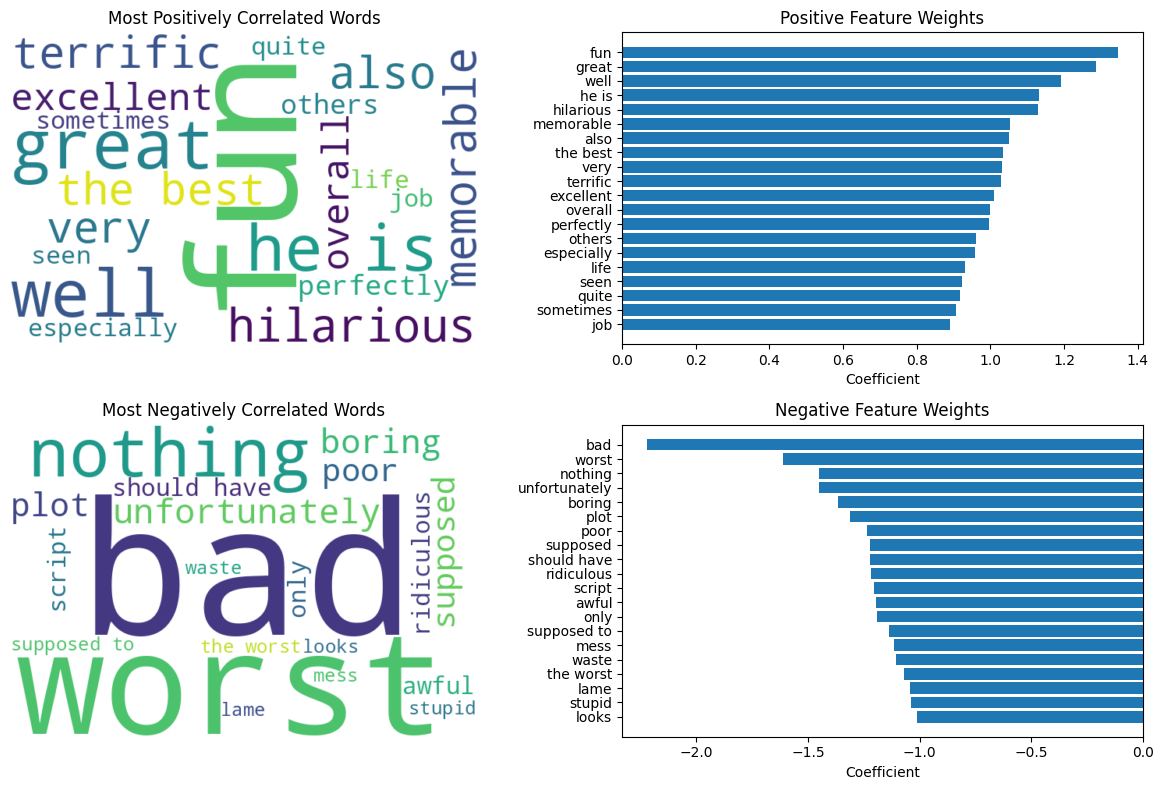

In [69]:
plot_wordclouds_and_coefficients(
    model_svc_tuned, save_file="figures/wc-coefs-svc-tuned.pdf"
)

In [28]:
model_logreg_tuned = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_df=0.9, min_df=3, ngram_range=(1, 2), sublinear_tf=True
            ),
        ),
        ("clf", LogisticRegression(C=10)),
    ]
)

scores_logreg_tuned = cross_validate(
    model_logreg_tuned, x, y, cv=cv, scoring=["accuracy", "f1", "precision", "recall"]
)

results_logreg_tuned = {
    "accuracy": np.mean(scores_logreg_tuned["test_accuracy"]),
    "f1": np.mean(scores_logreg_tuned["test_f1"]),
    "precision": np.mean(scores_logreg_tuned["test_precision"]),
    "recall": np.mean(scores_logreg_tuned["test_recall"]),
}

write_results_to_csv(results_logreg_tuned, "results/tuned-tfidf-logreg.csv")

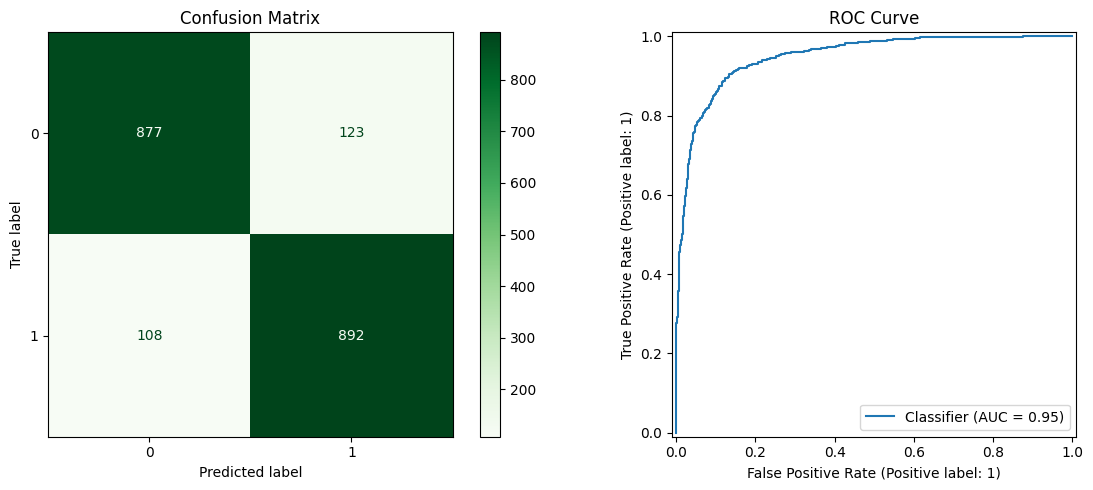

In [29]:
y_pred_logreg_tuned = cross_val_predict(model_logreg_tuned, x, y, cv=cv)
y_pred_logreg_tuned_proba = cross_val_predict(
    model_logreg_tuned, x, y, cv=cv, method="decision_function"
)  # Not proba in the case of Linearlogreg

create_confusion_matrix_and_roc_curve(
    y, y_pred_logreg_tuned, y_pred_logreg_tuned_proba, "figures/cm-roc-logreg-tuned.pdf"
)

In [81]:
# %%timeit

# model_logreg_tuned.fit(x, y)

1.96 s ± 212 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [82]:
# %%timeit

# pred_logreg_tuned = model_logreg_tuned.predict(x_unseen)

4.13 s ± 14.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [30]:
model_logreg_tuned.fit(x, y)
pred_logreg_tuned = model_logreg_tuned.predict(x_unseen)
write_solution(pred_logreg_tuned, "submissions/submission-movie-5-tuned-logreg.csv")

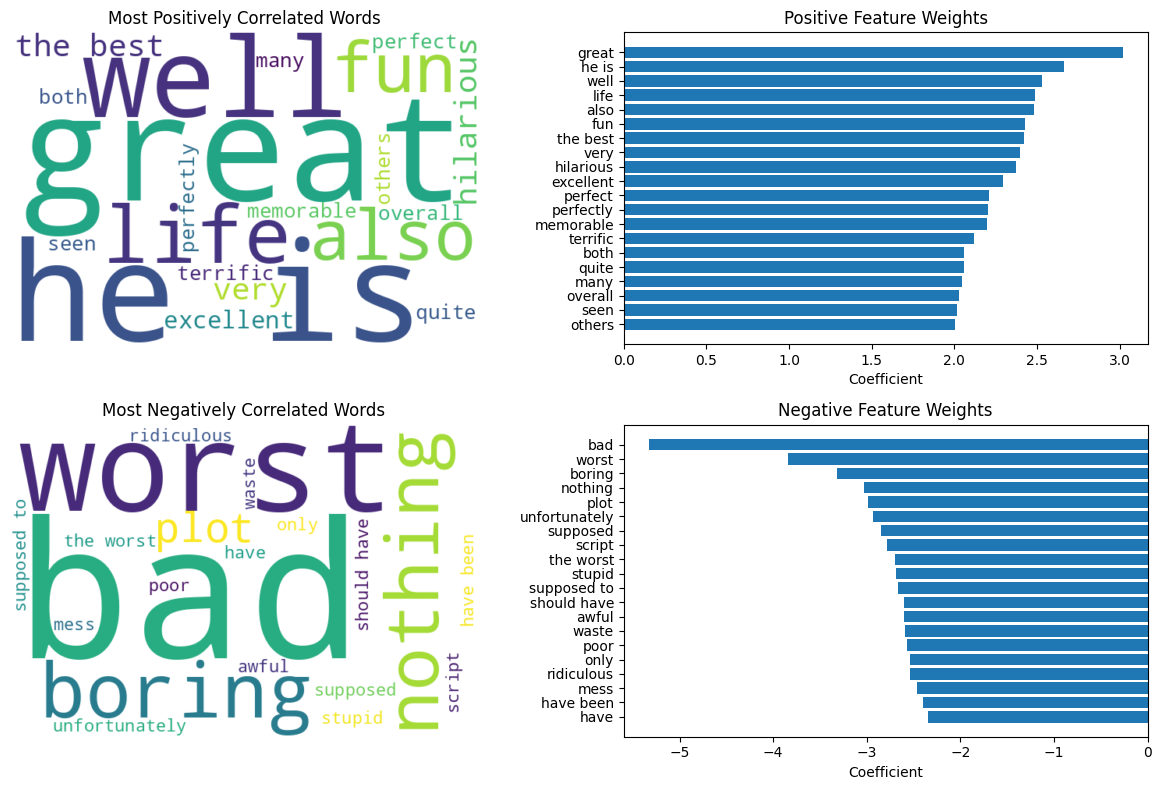

In [70]:
plot_wordclouds_and_coefficients(
    model_logreg_tuned, save_file="figures/wc-coefs-logreg-tuned.pdf.pdf"
)

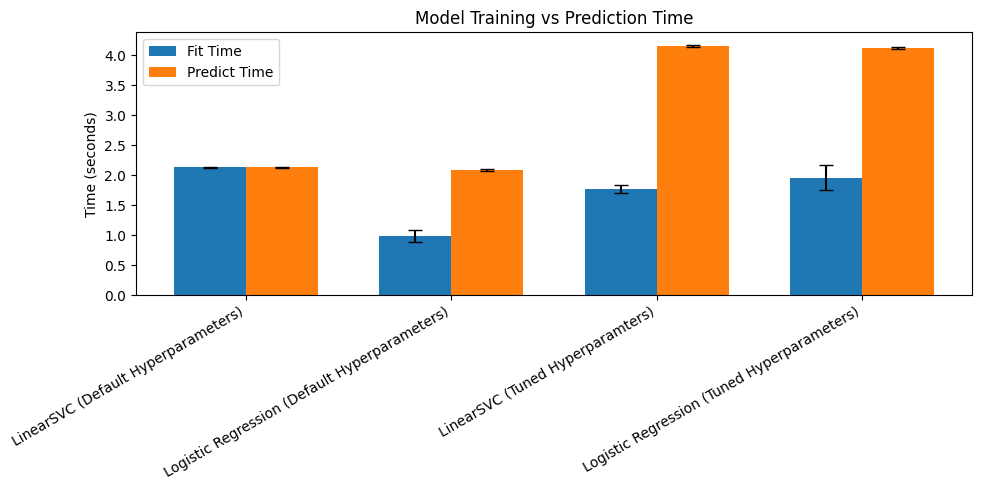

In [93]:
model_names = [
    "LinearSVC (Default Hyperparameters)",
    "Logistic Regression (Default Hyperparameters)",
    "LinearSVC (Tuned Hyperparamters)",
    "Logistic Regression (Tuned Hyperparameters)",
]

fit_times_s = [2.13, 0.979, 1.77, 1.96]
fit_times_std = [0.0125, 0.0991, 0.0693, 0.212]

predict_times_s = [2.13, 2.09, 4.16, 4.13]
predict_times_std = [0.0125, 0.0132, 0.0166, 0.0146]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))

# Fit time bars
plt.bar(
    x - width / 2,
    fit_times_s,
    width,
    yerr=fit_times_std,
    capsize=5,
    label="Fit Time",
)

# Predict time bars
plt.bar(
    x + width / 2,
    predict_times_s,
    width,
    yerr=predict_times_std,
    capsize=5,
    label="Predict Time",
)

plt.xticks(x, model_names, rotation=30, ha="right")
plt.ylabel("Time (seconds)")
plt.title("Model Training vs Prediction Time")
plt.legend()
plt.tight_layout()

plt.savefig("figures/tfidf-speed.pdf")
plt.show()

## RoBERTa

### Model 3: Transformer

Based on: https://huggingface.co/docs/transformers/tasks/sequence_classification

In [129]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, shuffle=True, random_state=0
)

Convert the data to match the example

In [130]:
from datasets import DatasetDict, Dataset

#### Dataset Preparation

In [131]:
movies = DatasetDict(
    {
        "train": Dataset.from_dict({"text": x_train, "label": y_train}),
        "test": Dataset.from_dict({"text": x_test, "label": y_test}),
        "unseen": Dataset.from_dict({"text": x_unseen}),
    }
)
movies

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 400
    })
    unseen: Dataset({
        features: ['text'],
        num_rows: 25000
    })
})

#### Preprocess

In [132]:
model_name = "FacebookAI/roberta-large"

In [133]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [134]:
def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512)

In [135]:
tokenized_movies = movies.map(tokenize, batched=True)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [34]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#### Evaluate

In [35]:
import evaluate

accuracy = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

#### Train

In [120]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training

In [37]:
# training_args = TrainingArguments(
#     output_dir="roberta-model",
#     learning_rate=2e-5,
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     # push_to_hub=True,
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_movies["train"],
#     eval_dataset=tokenized_movies["test"],
#     processing_class=tokenizer,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics,
# )

# trainer.train()

In [38]:
# trainer.save_model("roberta-model-save")

In [94]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="roberta-model-save",
    # config="roberta-model-save",
    # tokenizer="roberta-model-save",
    # device="cpu",
    truncation=True,
)
classifier

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

TextClassificationPipeline: {'model': 'RobertaForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [136]:
pred_test = classifier.predict(tokenized_movies["test"]["text"][:])
y_pred_test = [1 if pred["label"] == "LABEL_1" else 0 for pred in pred_test]
y_pred_test_proba = [
    pred["score"] if pred["label"] == "LABEL_1" else -pred["score"]
    for pred in pred_test
]

In [137]:
pred_train = classifier.predict(tokenized_movies["train"]["text"][:])
y_pred_train = [0 if pred["label"] == "LABEL_0" else 1 for pred in pred_train]

In [138]:
pred_unseen = classifier.predict(tokenized_movies["unseen"]["text"][:])
y_pred_unseen = [0 if pred["label"] == "LABEL_0" else 1 for pred in pred_unseen]

In [45]:
write_solution(y_pred_unseen, "submissions/submission-movie-6-roberta.csv")

In [124]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results_roberta = {
    "accuracy": accuracy_score(y_test, y_pred_test),
    "f1": f1_score(y_test, y_pred_test),
    "precision": precision_score(y_test, y_pred_test),
    "recall": recall_score(y_test, y_pred_test),
}

write_results_to_csv(results_roberta, "results/roberta.csv")

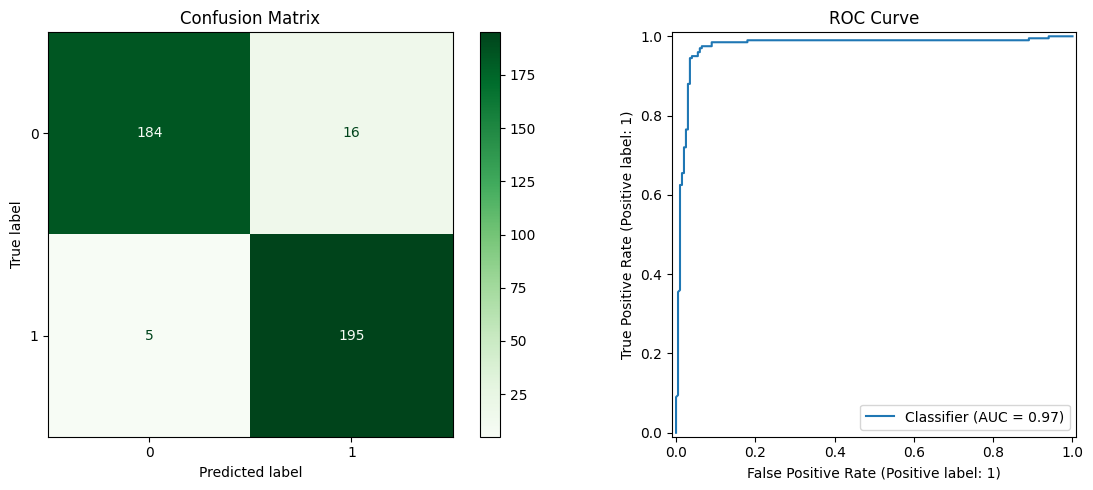

In [136]:
create_confusion_matrix_and_roc_curve(
    y_test, y_pred_test, y_pred_test_proba, "figures/cm-roc-roberta.pdf"
)

## GPT

In [ ]:
import ollama
from tqdm.notebook import tqdm

model_gpt = "qwen3.5:latest"


def predict(x):
    res = []

    for review in tqdm(x):
        prompt = f'Reply only with "positive" or "negative". Is the following movie review positive or negative: {review}'

        response = ollama.generate(model=model_gpt, prompt=prompt, think=False)

        response_cleaned = response["response"].strip().lower()

        if "positive" in response_cleaned:
            res.append(1)
        elif "negative" in response_cleaned:
            res.append(0)
        else:
            res.append(response_cleaned)

    return res

In [ ]:
y_pred_gpt = predict(x_test)

In [146]:
results_gpt = {
    "accuracy": accuracy_score(y_test, y_pred_gpt),
    "f1": f1_score(y_test, y_pred_gpt),
    "precision": precision_score(y_test, y_pred_gpt),
    "recall": recall_score(y_test, y_pred_gpt),
}

print(results_gpt)
write_results_to_csv(results_gpt, "results/gpt.csv")

{'accuracy': 0.9525, 'f1': 0.9518987341772152, 'precision': 0.9641025641025641, 'recall': 0.94}


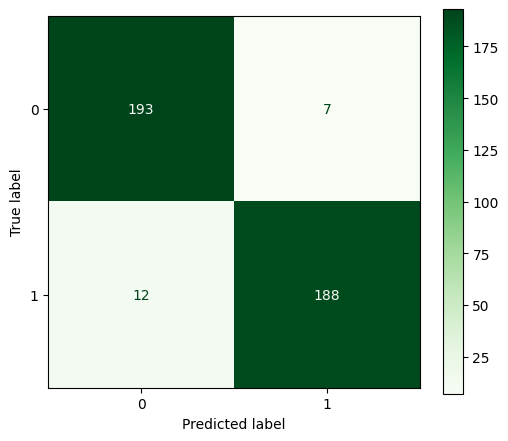

In [145]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gpt, ax=ax, cmap="Greens")
plt.savefig("figures/cm-roc-gpt.pdf")
plt.show()